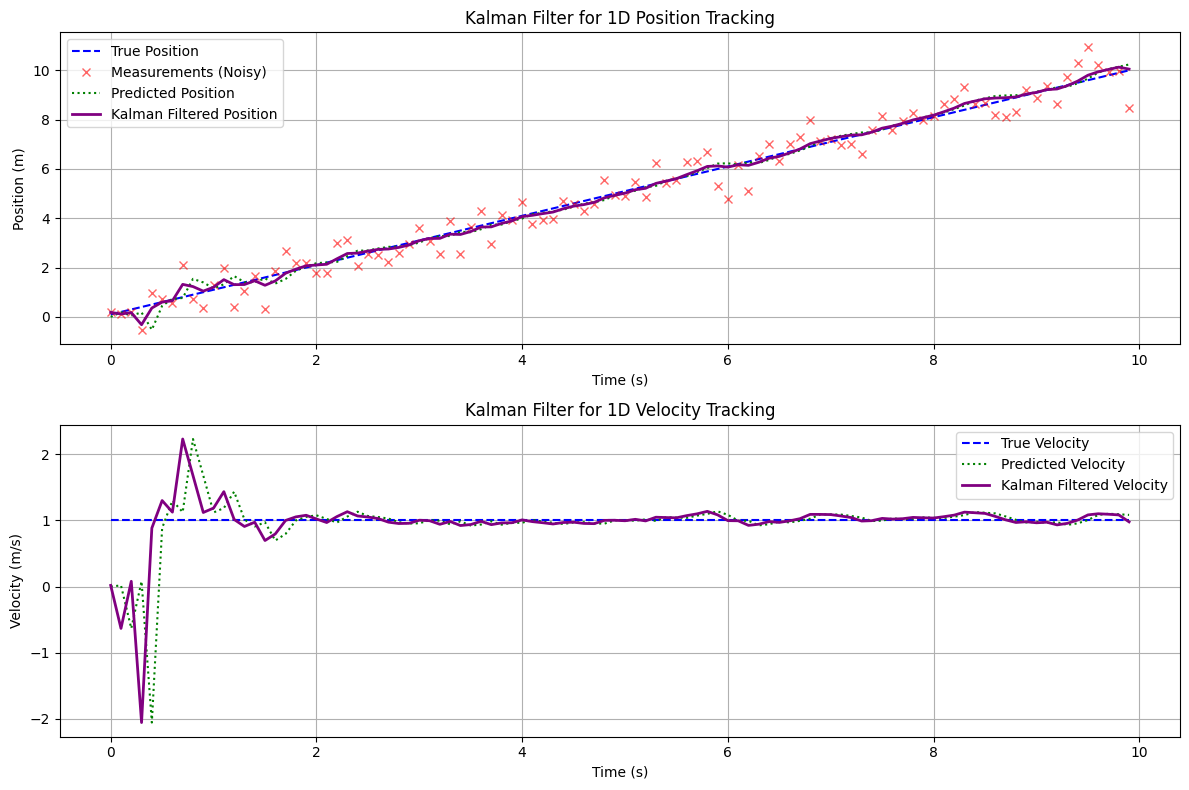


Final Kalman Filtered State (Position, Velocity):
[[10.05060592]
 [ 0.97805111]]

Final Covariance Matrix:
[[0.0265922  0.0149475 ]
 [0.0149475  0.01729019]]


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

# --- 1. Define the System ---
# We're tracking position (x) and velocity (v) in 1D.
# So our state vector x will be [position, velocity].
# dim_x = 2 (number of state variables)
# We only measure position.
# So our measurement vector z will be [position_measurement].
# dim_z = 1 (number of measurement inputs)

dt = 0.1 # Time step in seconds

# --- 2. Initialize the Kalman Filter Object ---
# Create the KalmanFilter object.
# dim_x: dimension of the state vector
# dim_z: dimension of the measurement vector
kf = KalmanFilter(dim_x=2, dim_z=1)

# --- 3. Set Initial State and Covariance ---
# Initial state estimate (x).
# We start with an estimated position of 0 and velocity of 0.
kf.x = np.array([[0.],    # position
                 [0.]])   # velocity

# Initial state covariance matrix (P).
# This represents our uncertainty about the initial state.
# Large values mean high uncertainty.
kf.P = np.array([[1000., 0.],  # Large uncertainty in initial position
                 [0., 1000.]]) # Large uncertainty in initial velocity
# A common way to initialize P is: kf.P *= 1000.  (multiplies the identity matrix by 1000)

# --- 4. Define State Transition Matrix (F) ---
# F describes how the state changes from one time step to the next.
# For constant velocity, the equations are:
# x_new = x_old + v_old * dt
# v_new = v_old
kf.F = np.array([[1., dt],   # New position depends on old position and old velocity * dt
                 [0., 1.]])  # New velocity is same as old velocity

# --- 5. Define Measurement Function Matrix (H) ---
# H describes how the state relates to the measurement.
# We only measure position.
# z = H * x
# z = [position_measurement]
# x = [position, velocity]
# So, [position_measurement] = [[1, 0]] * [position, velocity]
kf.H = np.array([[1., 0.]])

# --- 6. Define Measurement Noise Covariance (R) ---
# R represents the uncertainty in our measurements.
# A small R means we trust our sensor readings more.
measurement_noise_std = 0.5 # Standard deviation of measurement noise
kf.R = np.array([[measurement_noise_std**2]]) # R is a 1x1 matrix for 1D measurement

# --- 7. Define Process Noise Covariance (Q) ---
# Q represents the uncertainty in our system model (unmodeled accelerations, jerky motion, etc.).
# `Q_discrete_white_noise` is a convenient helper function in filterpy.
# It assumes discrete white noise affecting acceleration.
# dim: dimension of the state for which noise is applied (e.g., if velocity is noisy, dim=1 for velocity)
# dt: time step
# var: variance of the white noise
kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=0.1, block_size=1, order_by_dim=True)
# You might need to adjust 'var' based on your system.
# For a constant velocity model, process noise often affects acceleration,
# which then influences position and velocity.
# A small 'var' means we assume the object moves very smoothly.

kf.B = 0

# --- 8. Simulate Data and Run the Filter ---
# Simulate true data (e.g., an object moving at a constant velocity)
true_position = []
true_velocity = []
current_true_pos = 0.0
current_true_vel = 1.0 # meters/second

for i in range(100):
    current_true_pos += current_true_vel * dt # Simple constant velocity motion
    true_position.append(current_true_pos)
    true_velocity.append(current_true_vel)

# Generate noisy measurements
measurements = [p + np.random.normal(0, measurement_noise_std) for p in true_position]

# Store results
filtered_positions = []
filtered_velocities = []
predicted_positions = [] # To see the prediction step
predicted_velocities = []

for z in measurements:
    # Prediction step
    kf.predict()
    # kf.predict()
    for _ in range(20):
        kf.get_prediction()
    # kf.predict()
    # kf.predict()
    # kf.predict()
    # kf.predict()
    # kf.predict()
    predicted_positions.append(kf.x[0, 0])
    predicted_velocities.append(kf.x[1, 0])

    # Update step with the new measurement
    kf.update(z)
    filtered_positions.append(kf.x[0, 0])
    filtered_velocities.append(kf.x[1, 0])

# --- 9. Plot the Results ---
time_steps = np.arange(len(measurements)) * dt

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(time_steps, true_position, label='True Position', linestyle='--', color='blue')
plt.plot(time_steps, measurements, label='Measurements (Noisy)', marker='x', linestyle='', alpha=0.6, color='red')
plt.plot(time_steps, predicted_positions, label='Predicted Position', linestyle=':', color='green')
plt.plot(time_steps, filtered_positions, label='Kalman Filtered Position', color='purple', linewidth=2)
plt.title('Kalman Filter for 1D Position Tracking')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(time_steps, true_velocity, label='True Velocity', linestyle='--', color='blue')
plt.plot(time_steps, predicted_velocities, label='Predicted Velocity', linestyle=':', color='green')
plt.plot(time_steps, filtered_velocities, label='Kalman Filtered Velocity', color='purple', linewidth=2)
plt.title('Kalman Filter for 1D Velocity Tracking')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nFinal Kalman Filtered State (Position, Velocity):")
print(kf.x)
print("\nFinal Covariance Matrix:")
print(kf.P)

In [11]:
import numpy as np
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

kf = KalmanFilter(dim_x=2, dim_z=1)
dt = 0.1

kf.x = np.array([[0.], [0.]])
kf.P = np.eye(2) * 10.0
kf.F = np.array([[1., dt], [0., 1.]])
kf.H = np.array([[1., 0.]])
kf.R = np.array([[0.1**2]])
kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=0.01)
kf.B = 0

print("Initial kf.x:\n", kf.x)
print("Initial kf.P:\n", kf.P)

# --- Using get_prediction() ---
# This calculates the prediction but DOES NOT change kf.x or kf.P
predicted_x_from_get, predicted_P_from_get = kf.get_prediction()

print("\n--- After get_prediction() ---")
print("kf.x (unchanged):\n", kf.x)
print("kf.P (unchanged):\n", kf.P)
print("Predicted x from get_prediction():\n", predicted_x_from_get)
print("Predicted P from get_prediction():\n", predicted_P_from_get)


# --- Using predict() ---
# This calculates the prediction AND CHANGES kf.x and kf.P
kf.predict()

print("\n--- After predict() ---")
print("kf.x (updated to predicted state):\n", kf.x)
print("kf.P (updated to predicted covariance):\n", kf.P)
print("kf.x_prior (stores the prediction made by predict()):\n", kf.x_prior)
print("kf.P_prior (stores the prediction made by predict()):\n", kf.P_prior)

Initial kf.x:
 [[0.]
 [0.]]
Initial kf.P:
 [[10.  0.]
 [ 0. 10.]]

--- After get_prediction() ---
kf.x (unchanged):
 [[0.]
 [0.]]
kf.P (unchanged):
 [[10.  0.]
 [ 0. 10.]]
Predicted x from get_prediction():
 [[0.]
 [0.]]
Predicted P from get_prediction():
 [[10.10000025  1.000005  ]
 [ 1.000005   10.0001    ]]

--- After predict() ---
kf.x (updated to predicted state):
 [[0.]
 [0.]]
kf.P (updated to predicted covariance):
 [[10.10000025  1.000005  ]
 [ 1.000005   10.0001    ]]
kf.x_prior (stores the prediction made by predict()):
 [[0.]
 [0.]]
kf.P_prior (stores the prediction made by predict()):
 [[10.10000025  1.000005  ]
 [ 1.000005   10.0001    ]]
